Dataset je učitan iz CSV fajla, target je izdvojen kao labela, feature kolone su podeljene na numeričke i kategoričke, a zatim je urađena podela na train/test (80/20) sa fiksiranim seed-om radi reproduktivnosti.

In [148]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import shap
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

df = pd.read_csv("../data/processed_cleveland.csv")

X = df.drop("target", axis=1)
y = df["target"]

# kolone
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Preprocessing je implementiran pomoću ColumnTransformer objekta, gde se numerički atributi standardizuju, a kategorički enkoduju one-hot metodom.

In [149]:
preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

In [150]:
preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

Funkcija rekonstruiše nazive feature-a nakon preprocessing-a kako bi omogućila ispravnu interpretaciju modela.

In [151]:
def get_feature_names(ct: ColumnTransformer):
    # vrati feature names nakon ColumnTransformer-a
    num_features = ct.named_transformers_["num"]
    cat_ohe = ct.named_transformers_["cat"]

    # num
    if num_features == "passthrough":
        num_names = num_cols
    else:
        num_names = num_cols  # scaler ne menja imena

    # cat
    cat_names = cat_ohe.get_feature_names_out(cat_cols).tolist()
    return num_names + cat_names

Trenirana su dva modela logistička regresija i random forest, uz prethodnu primenu odgovarajućeg preprocessing-a nad podacima. Transformacije su primenjene na trening i test skup, nakon čega su modeli obučeni.

In [152]:
# Logistic Regression
lr = LogisticRegression(max_iter=5000, solver="lbfgs")
X_train_lr = preprocess_lr.fit_transform(X_train)
X_test_lr  = preprocess_lr.transform(X_test)
lr.fit(X_train_lr, y_train)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
X_train_rf = preprocess_rf.fit_transform(X_train)
X_test_rf  = preprocess_rf.transform(X_test)
rf.fit(X_train_rf, y_train)

# feature names
feat_lr = get_feature_names(preprocess_lr)
feat_rf = get_feature_names(preprocess_rf)

SHAP analiza je primenjena radi interpretacije logističke regresije. Grafikon prikazuje doprinos i značaj svakog atributa u procesu predikcije.

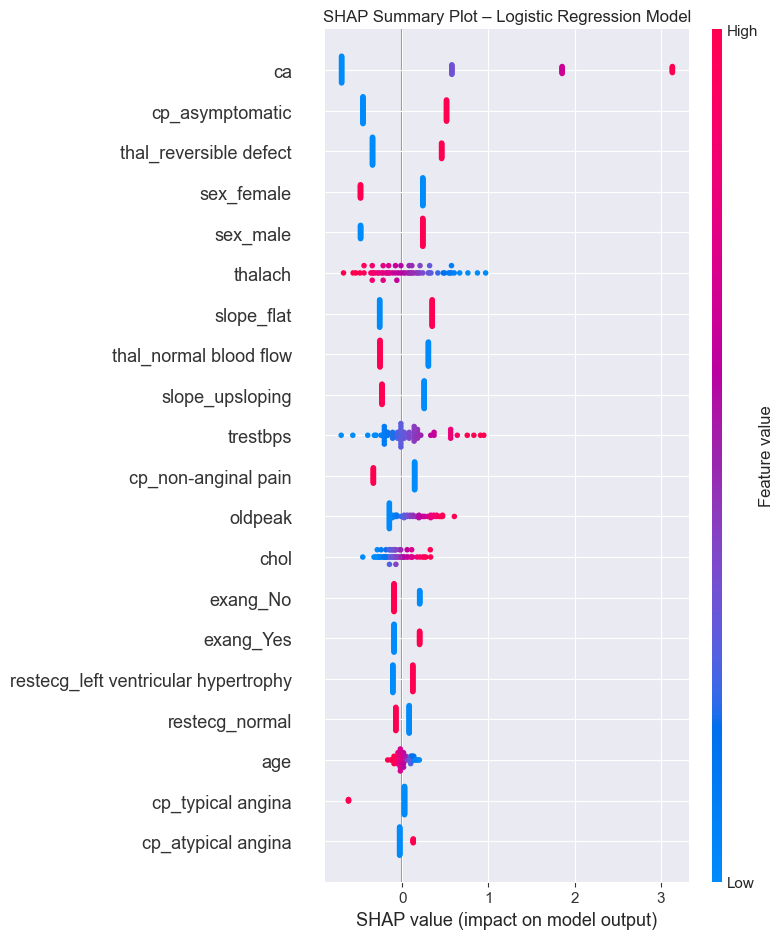

In [162]:
# SHAP LR
masker = shap.maskers.Independent(X_train_lr)

explainer_lr = shap.LinearExplainer(
    lr,
    masker
)

shap_values_lr = explainer_lr(X_test_lr)

# Summary plot (LR)
shap.summary_plot(
    shap_values_lr.values,
    features=X_test_lr,
    feature_names=feat_lr,
    show=False   # VAŽNO
)

plt.title("SHAP Summary Plot – Logistic Regression Model")
plt.tight_layout()
plt.show()


SHAP TreeExplainer je primenjen radi interpretacije Random Forest modela. Grafikon prikazuje doprinos pojedinačnih atributa.

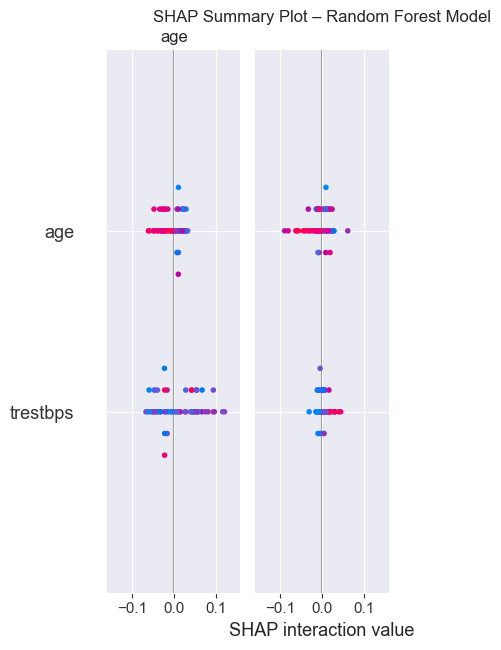

In [171]:
# SHAP RF
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test_rf)

# Kod binary klasifikacije, shap_values_rf može biti lista [class0, class1]
# Nama je interesantna klasa 1 (target=1).
if isinstance(shap_values_rf, list):
    sv_rf = shap_values_rf[1]
else:
    sv_rf = shap_values_rf

shap.summary_plot(
    sv_rf,
    features=X_test_rf,
    feature_names=feat_rf,
    show=False
)

plt.title("SHAP Summary Plot – Random Forest Model", pad=20)

plt.subplots_adjust(left=0.35)  # povećaj ako treba (0.30–0.40)
plt.tight_layout()
plt.show()

Funkcija to_2d_shap standardizuje SHAP vrednosti u 2D format pogodan za dalju analizu. Funkcija top_shap_features izračunava i rangira najvažnije atribute na osnovu prosečne apsolutne SHAP vrednosti.

In [155]:
def to_2d_shap(shap_obj, class_index=1):
    """
    Vrati SHAP vrednosti kao 2D matricu (n_samples, n_features).
    Radi za:
    - shap.Explanation (novi API)
    - list/ndarray iz TreeExplainer(shap_values)
    """
    # shap.Explanation
    if hasattr(shap_obj, "values"):
        vals = shap_obj.values
    else:
        vals = shap_obj

    # Ako je lista (npr. [class0, class1])
    if isinstance(vals, list):
        vals = vals[class_index]

    vals = np.array(vals)

    # Ako je 3D: (n_samples, n_features, n_classes) ili (n_samples, n_features, n_outputs)
    if vals.ndim == 3:
        vals = vals[:, :, class_index]

    # Sada mora biti 2D
    if vals.ndim != 2:
        raise ValueError(f"Expected 2D shap values, got shape {vals.shape}")

    return vals


def top_shap_features(shap_vals_2d, feature_names, top_n=10):
    mean_abs = np.mean(np.abs(shap_vals_2d), axis=0)  # (n_features,)
    if len(mean_abs) != len(feature_names):
        raise ValueError(f"Feature mismatch: mean_abs={len(mean_abs)} vs names={len(feature_names)}")
    return pd.Series(mean_abs, index=feature_names).sort_values(ascending=False).head(top_n)

SHAP vrednosti su obrađene i rangirane kako bi se izdvojili najvažniji atributi koji najviše utiču na predikciju logističke regresije.

In [156]:
sv_lr_2d = to_2d_shap(shap_values_lr, class_index=1)  # kod LR je često već 2D, ali ovo je “safe”
top_lr = top_shap_features(sv_lr_2d, feat_lr, top_n=10)

Izračunate su i prikazane najvažnije SHAP karakteristike za oba modela radi njihovog poređenja.

In [157]:
sv_rf_2d = to_2d_shap(shap_values_rf, class_index=1)
top_rf = top_shap_features(sv_rf_2d, feat_rf, top_n=10)

print("Top LR:\n", top_lr)
print("\nTop RF:\n", top_rf)

Top LR:
 ca                        1.166376
cp_asymptomatic           0.481004
thal_reversible defect    0.385088
sex_female                0.319011
sex_male                  0.318476
thalach                   0.304139
slope_flat                0.303886
thal_normal blood flow    0.279624
slope_upsloping           0.246057
trestbps                  0.239238
dtype: float64

Top RF:
 thal_normal blood flow    0.083823
ca                        0.083054
cp_asymptomatic           0.065395
thal_reversible defect    0.060189
oldpeak                   0.045287
thalach                   0.037474
exang_Yes                 0.025467
slope_upsloping           0.024241
slope_flat                0.022132
age                       0.021386
dtype: float64


Ovi grafici prikazuju kako konkretne promenljive utiču na predikciju modela, odnosno kako se njihov doprinos menja u zavisnosti od njihove vrednosti.

Analiza dependence grafika potvrđuje da atributi „oldpeak“ i „age“ imaju značajan i klinički smislen uticaj na predikciju srčanog udara, pri čemu Random Forest model detektuje i nelinearne obrasce u podacima.

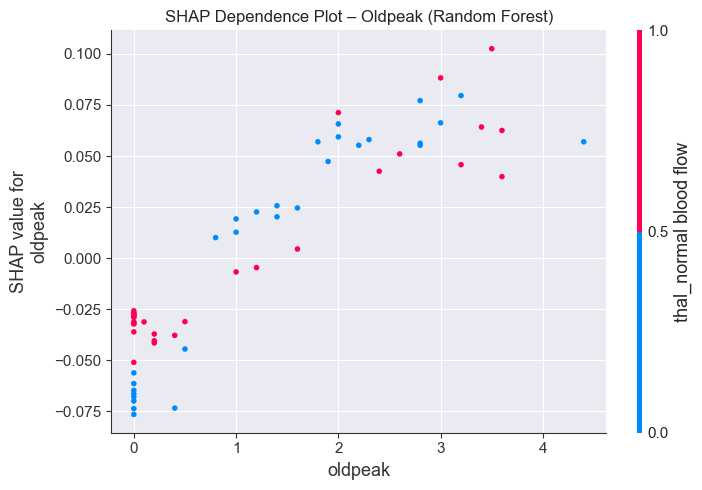

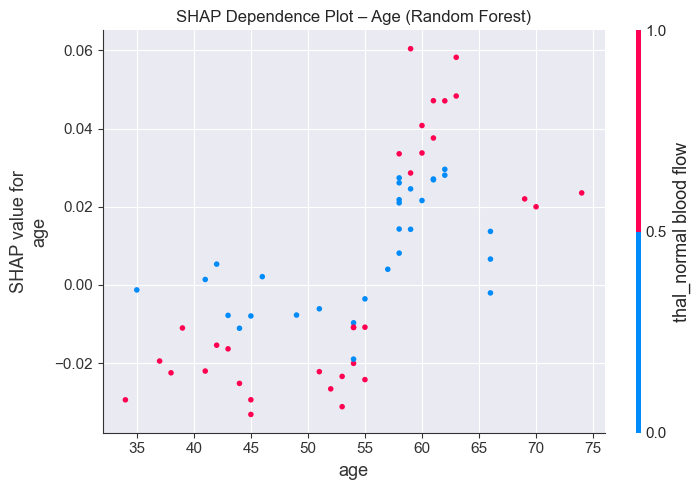

In [173]:
# --- RF SHAP vrednosti već imamo ---
# sv_rf_2d = to_2d_shap(shap_values_rf, class_index=1)

# Oldpeak
shap.dependence_plot(
    "oldpeak",
    sv_rf_2d,
    X_test_rf,
    feature_names=feat_rf,
    show=False
)
plt.title("SHAP Dependence Plot – Oldpeak (Random Forest)")
plt.tight_layout()
plt.show()


# Age
shap.dependence_plot(
    "age",
    sv_rf_2d,
    X_test_rf,
    feature_names=feat_rf,
    show=False
)
plt.title("SHAP Dependence Plot – Age (Random Forest)")
plt.tight_layout()
plt.show()


Za razliku od Random Forest modela, kod logističke regresije uočavamo gotovo linearan odnos između atributa i predikcije, što je očekivano s obzirom na linearnu prirodu modela.

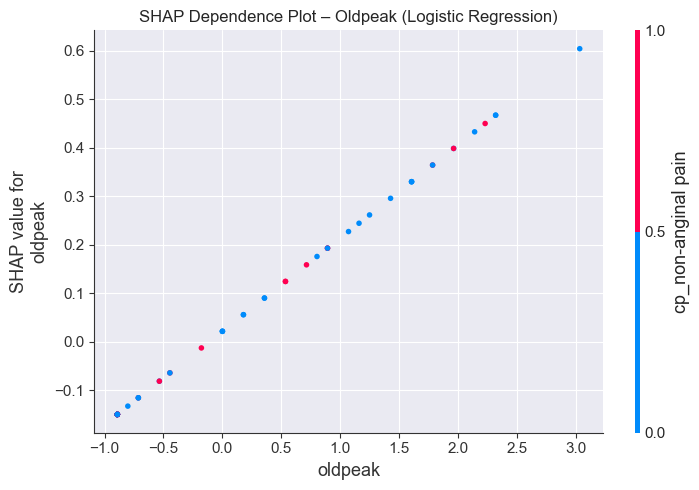

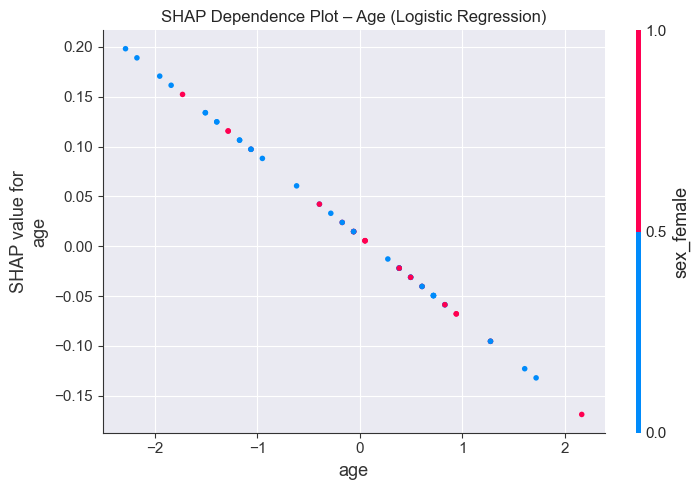

In [175]:
# sv_lr_2d = to_2d_shap(shap_values_lr, class_index=1)

shap.dependence_plot(
    "oldpeak",
    sv_lr_2d,
    X_test_lr,
    feature_names=feat_lr,
    show=False
)
plt.title("SHAP Dependence Plot – Oldpeak (Logistic Regression)")
plt.tight_layout()
plt.show()


shap.dependence_plot(
    "age",
    sv_lr_2d,
    X_test_lr,
    feature_names=feat_lr,
    show=False
)
plt.title("SHAP Dependence Plot – Age (Logistic Regression)")
plt.tight_layout()
plt.show()